In [3]:
"""
============================================================
PROYECTO OCR AVANZADO - VERSIÓN 3.0
Sistema completo con entrenamiento masivo y manuscrito
============================================================
2 SEMANAS DE TIEMPO - VAMOS A HACERLO BIEN
============================================================
"""

# ============================================================
# CELDA 1: Setup y Verificación de GPU
# ============================================================
import torch
import sys
import os

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ GPU no disponible, entrenamiento será MUY lento")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch version: 2.9.0+cpu
CUDA available: False
⚠️ GPU no disponible, entrenamiento será MUY lento


In [4]:
# ============================================================
# CELDA 2: Montar Google Drive (CRÍTICO para no perder progreso)
# ============================================================
from google.colab import drive
import os
from pathlib import Path

# Montar Drive
drive.mount('/content/drive')

# Crear estructura en Drive para persistencia
DRIVE_ROOT = Path('/content/drive/MyDrive/OCR_Project')
DRIVE_CHECKPOINTS = DRIVE_ROOT / 'checkpoints'
DRIVE_MODELS = DRIVE_ROOT / 'models'
DRIVE_DATASETS = DRIVE_ROOT / 'datasets'
DRIVE_RESULTS = DRIVE_ROOT / 'results'

for folder in [DRIVE_ROOT, DRIVE_CHECKPOINTS, DRIVE_MODELS, DRIVE_DATASETS, DRIVE_RESULTS]:
    folder.mkdir(parents=True, exist_ok=True)

print("✅ Google Drive montado y estructura creada:")
print(f"   - Checkpoints: {DRIVE_CHECKPOINTS}")
print(f"   - Modelos: {DRIVE_MODELS}")
print(f"   - Datasets: {DRIVE_DATASETS}")
print(f"   - Resultados: {DRIVE_RESULTS}")

Mounted at /content/drive
✅ Google Drive montado y estructura creada:
   - Checkpoints: /content/drive/MyDrive/OCR_Project/checkpoints
   - Modelos: /content/drive/MyDrive/OCR_Project/models
   - Datasets: /content/drive/MyDrive/OCR_Project/datasets
   - Resultados: /content/drive/MyDrive/OCR_Project/results


In [5]:
# ============================================================
# CELDA 3: Instalación de Dependencias
# ============================================================
!pip install -q opencv-python-headless
!pip install -q pillow
!pip install -q matplotlib
!pip install -q scikit-image
!pip install -q albumentations
!pip install -q editdistance
!pip install -q tqdm
!pip install -q python-Levenshtein
!pip install -q tensorboard

print("✅ Dependencias instaladas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 22.0 MB/s eta 0:00:00
✅ Dependencias instaladas


In [6]:
# ============================================================
# CELDA 4: Imports y Configuración
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms as transforms
import torchvision.models as models
from tqdm import tqdm
import editdistance
import albumentations as A
from albumentations.pytorch import ToTensorV2
import string
import random
import json
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("✅ Imports completados y semilla establecida")

✅ Imports completados y semilla establecida


In [7]:
# ============================================================
# CELDA 5: Configuración Global del Proyecto
# ============================================================

class Config:
    """Configuración centralizada del proyecto"""

    # Vocabulario extendido
    CHARS = (
        string.ascii_letters +      # a-z, A-Z
        string.digits +              # 0-9
        string.punctuation +         # Símbolos
        ' ' +                        # Espacio
        'áéíóúÁÉÍÓÚñÑüÜ¿¡'          # Español
    )

    CHAR_TO_IDX = {char: idx + 1 for idx, char in enumerate(CHARS)}
    IDX_TO_CHAR = {idx: char for char, idx in CHAR_TO_IDX.items()}
    IDX_TO_CHAR[0] = '<blank>'
    NUM_CLASSES = len(CHAR_TO_IDX) + 1

    # Arquitectura del modelo
    IMG_HEIGHT = 64
    IMG_WIDTH = 256
    HIDDEN_SIZE = 512
    NUM_LSTM_LAYERS = 3

    # Entrenamiento
    BATCH_SIZE = 128  # Aumentado para aprovechar GPU
    NUM_WORKERS = 2
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-4

    # Dataset
    TRAIN_SIZE = 100000  # 100k imágenes de entrenamiento
    VAL_SIZE = 10000     # 10k validación
    TEST_SIZE = 5000     # 5k test

    # Épocas y early stopping
    MAX_EPOCHS = 200
    EARLY_STOP_PATIENCE = 20

    # Checkpointing
    SAVE_EVERY_N_EPOCHS = 5
    KEEP_LAST_N_CHECKPOINTS = 5

    # Paths
    CHECKPOINT_DIR = DRIVE_CHECKPOINTS
    MODEL_DIR = DRIVE_MODELS
    RESULTS_DIR = DRIVE_RESULTS

config = Config()

print(f"✅ Configuración cargada:")
print(f"   Vocabulario: {config.NUM_CLASSES} clases")
print(f"   Dataset train: {config.TRAIN_SIZE:,} imágenes")
print(f"   Épocas máximas: {config.MAX_EPOCHS}")
print(f"   Batch size: {config.BATCH_SIZE}")

✅ Configuración cargada:
   Vocabulario: 112 clases
   Dataset train: 100,000 imágenes
   Épocas máximas: 200
   Batch size: 128


In [8]:
# ============================================================
# CELDA 6: Utilidades de Codificación/Decodificación
# ============================================================

def encode_text(text):
    """Convierte texto a índices"""
    encoded = []
    for char in text:
        if char in config.CHAR_TO_IDX:
            encoded.append(config.CHAR_TO_IDX[char])
    return encoded if encoded else [0]  # Al menos un blank si está vacío

def decode_prediction(indices):
    """Convierte índices a texto con CTC decode"""
    chars = []
    prev_idx = -1
    for idx in indices:
        if idx != 0 and idx != prev_idx:
            char = config.IDX_TO_CHAR.get(idx, '')
            if char and char != '<blank>':
                chars.append(char)
        prev_idx = idx
    return ''.join(chars)

def calculate_cer(pred, truth):
    """Character Error Rate"""
    if len(truth) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    return editdistance.eval(pred, truth) / len(truth)

def calculate_wer(pred, truth):
    """Word Error Rate"""
    pred_words = pred.split()
    truth_words = truth.split()
    if len(truth_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0
    return editdistance.eval(pred_words, truth_words) / len(truth_words)

def calculate_accuracy(pred, truth):
    """Exact match accuracy"""
    return 1.0 if pred.strip() == truth.strip() else 0.0

print("✅ Utilidades definidas")


✅ Utilidades definidas


In [9]:
# ============================================================
# CELDA 7: Dataset Sintético Mejorado V2
# ============================================================

class AdvancedSyntheticDataset(Dataset):
    """
    Dataset sintético mejorado con mucha más variedad
    Enfocado en texto impreso de alta calidad
    """

    def __init__(self, num_samples, img_height=64, img_width=256, transform=None):
        self.num_samples = num_samples
        self.img_height = img_height
        self.img_width = img_width
        self.transform = transform

        # Vocabulario extendido
        self.words_spanish = self._load_spanish_words()
        self.words_english = self._load_english_words()
        self.numbers = self._create_number_patterns()
        self.codes = self._create_code_patterns()
        self.phrases = self._create_common_phrases()

        # Cargar fuentes
        self.fonts = self._load_fonts()

        print(f"Dataset creado:")
        print(f"  - {len(self.words_spanish)} palabras español")
        print(f"  - {len(self.words_english)} palabras inglés")
        print(f"  - {len(self.numbers)} patrones numéricos")
        print(f"  - {len(self.codes)} patrones de códigos")
        print(f"  - {len(self.phrases)} frases comunes")
        print(f"  - {len(self.fonts) if self.fonts else 0} fuentes disponibles")

    def _load_spanish_words(self):
        """Palabras en español (más completas)"""
        return [
            # Palabras básicas
            'el', 'la', 'de', 'que', 'y', 'a', 'en', 'un', 'ser', 'se', 'no',
            'haber', 'por', 'con', 'su', 'para', 'como', 'estar', 'tener',

            # Sustantivos comunes
            'casa', 'hombre', 'mujer', 'día', 'año', 'tiempo', 'vida', 'mano',
            'parte', 'mundo', 'ciudad', 'trabajo', 'país', 'empresa', 'persona',
            'momento', 'agua', 'calle', 'familia', 'lugar', 'hijo', 'padre',
            'madre', 'hermano', 'amigo', 'mesa', 'puerta', 'ventana', 'libro',

            # Verbos
            'hacer', 'decir', 'ir', 'ver', 'dar', 'saber', 'querer', 'llegar',
            'pasar', 'deber', 'poner', 'parecer', 'quedar', 'creer', 'hablar',
            'llevar', 'dejar', 'seguir', 'encontrar', 'llamar', 'venir', 'pensar',

            # Adjetivos
            'grande', 'bueno', 'nuevo', 'primero', 'último', 'largo', 'pequeño',
            'mejor', 'mismo', 'otro', 'propio', 'general', 'social', 'público',

            # Palabras con acentos (IMPORTANTE)
            'café', 'médico', 'música', 'teléfono', 'difícil', 'fácil', 'árbol',
            'español', 'inglés', 'francés', 'alemán', 'José', 'María', 'Andrés',
            'Inés', 'Raúl', 'Ángel', 'Víctor', 'código', 'función', 'solución',
            'información', 'decisión', 'versión', 'país', 'más', 'está', 'será',
            'pasó', 'aquí', 'allí', 'así', 'sí', 'después', 'además', 'también',

            # Ciudades
            'Madrid', 'Barcelona', 'Valencia', 'Sevilla', 'Málaga', 'Bilbao',

            # Nombres propios
            'Juan', 'Ana', 'Carlos', 'Elena', 'David', 'Laura', 'Miguel', 'Sara',
            'Pedro', 'Carmen', 'Antonio', 'Isabel', 'Francisco', 'Rosa', 'Manuel',
        ]

    def _load_english_words(self):
        """Palabras en inglés comunes"""
        return [
            'the', 'be', 'to', 'of', 'and', 'a', 'in', 'that', 'have', 'I',
            'it', 'for', 'not', 'on', 'with', 'he', 'as', 'you', 'do', 'at',
            'this', 'but', 'his', 'by', 'from', 'they', 'we', 'say', 'her',
            'she', 'or', 'an', 'will', 'my', 'one', 'all', 'would', 'there',
            'their', 'what', 'so', 'up', 'out', 'if', 'about', 'who', 'get',
            'which', 'go', 'me', 'when', 'make', 'can', 'like', 'time', 'no',
            'just', 'him', 'know', 'take', 'people', 'into', 'year', 'your',
            'good', 'some', 'could', 'them', 'see', 'other', 'than', 'then',
            'now', 'look', 'only', 'come', 'its', 'over', 'think', 'also',
            'back', 'after', 'use', 'two', 'how', 'our', 'work', 'first',
            'well', 'way', 'even', 'new', 'want', 'because', 'any', 'these',
            'give', 'day', 'most', 'us', 'document', 'file', 'code', 'system',
        ]

    def _create_number_patterns(self):
        """Patrones numéricos variados"""
        patterns = []

        # Números simples (0-9999)
        patterns.extend([str(i) for i in range(0, 100)])
        patterns.extend([str(i) for i in range(100, 10000, 100)])

        # Decimales
        for i in range(100):
            patterns.append(f"{random.randint(0,999)}.{random.randint(0,99)}")
            patterns.append(f"{random.randint(0,999)},{random.randint(0,99)}")

        # Fechas (varios formatos)
        for _ in range(50):
            d, m, y = random.randint(1,28), random.randint(1,12), random.randint(2020,2025)
            patterns.extend([
                f"{d}/{m}/{y}",
                f"{d:02d}/{m:02d}/{y}",
                f"{d}-{m}-{y}",
                f"{y}-{m:02d}-{d:02d}"
            ])

        # Teléfonos
        for _ in range(30):
            patterns.append(f"+34 {random.randint(600,799)} {random.randint(100,999)} {random.randint(100,999)}")
            patterns.append(f"{random.randint(600,799)}{random.randint(100,999)}{random.randint(100,999)}")

        # Precios
        for _ in range(50):
            patterns.append(f"{random.randint(1,999)}.{random.randint(0,99):02d}€")
            patterns.append(f"${random.randint(1,999)}.{random.randint(0,99):02d}")

        return patterns

    def _create_code_patterns(self):
        """Códigos alfanuméricos"""
        patterns = []

        # Códigos aleatorios
        for _ in range(100):
            length = random.randint(6, 12)
            code = ''.join(random.choices(string.ascii_uppercase + string.digits, k=length))
            patterns.append(code)

        # Códigos con guiones
        for _ in range(50):
            parts = [
                ''.join(random.choices(string.ascii_uppercase + string.digits, k=random.randint(3,5)))
                for _ in range(random.randint(2,4))
            ]
            patterns.append('-'.join(parts))

        # Matrículas españolas
        for _ in range(30):
            num = random.randint(1000, 9999)
            letters = ''.join(random.choices(string.ascii_uppercase, k=3))
            patterns.append(f"{num}{letters}")

        return patterns

    def _create_common_phrases(self):
        """Frases comunes en documentos"""
        return [
            'Total a pagar', 'Fecha de entrega', 'Número de referencia',
            'Dirección postal', 'Código postal', 'Teléfono de contacto',
            'Nombre completo', 'Apellidos', 'Documento de identidad',
            'Fecha de nacimiento', 'Lugar de nacimiento', 'Estado civil',
            'Profesión u oficio', 'Correo electrónico', 'Número de teléfono',
            'Código de producto', 'Precio unitario', 'Cantidad solicitada',
            'Total de la compra', 'Método de pago', 'Número de pedido',
            'Fecha de emisión', 'Fecha de vencimiento', 'Firma del titular',
            'Sello de la empresa', 'Razón social', 'CIF/NIF', 'Domicilio fiscal',
        ]

    def _load_fonts(self):
        """Carga fuentes del sistema"""
        font_paths = [
            '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
            '/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',
            '/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf',
            '/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf',
            '/usr/share/fonts/truetype/liberation/LiberationSerif-Regular.ttf',
            '/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf',
        ]

        fonts = [f for f in font_paths if os.path.exists(f)]
        return fonts if fonts else None

    def generate_text(self):
        """Genera texto con distribución balanceada"""
        text_type = random.choices(
            ['word_spanish', 'word_english', 'words', 'number', 'code', 'phrase'],
            weights=[25, 15, 25, 15, 10, 10],  # Distribución balanceada
            k=1
        )[0]

        if text_type == 'word_spanish':
            return random.choice(self.words_spanish)
        elif text_type == 'word_english':
            return random.choice(self.words_english)
        elif text_type == 'words':
            num_words = random.randint(2, 5)
            words = random.choices(self.words_spanish + self.words_english, k=num_words)
            return ' '.join(words)
        elif text_type == 'number':
            return random.choice(self.numbers)
        elif text_type == 'code':
            return random.choice(self.codes)
        else:  # phrase
            return random.choice(self.phrases)

    def create_image(self, text):
        """Crea imagen con texto"""
        # Fondo
        if random.random() > 0.8:
            bg = random.randint(230, 255)
            img = Image.new('RGB', (self.img_width, self.img_height), (bg, bg, bg))
        else:
            img = Image.new('RGB', (self.img_width, self.img_height), 'white')

        draw = ImageDraw.Draw(img)

        # Fuente
        font_size = random.randint(28, 48)
        try:
            if self.fonts:
                font_path = random.choice(self.fonts)
                font = ImageFont.truetype(font_path, font_size)
            else:
                font = ImageFont.load_default()
        except:
            font = ImageFont.load_default()

        # Color texto
        text_gray = random.randint(0, 50)
        text_color = (text_gray, text_gray, text_gray)

        # Posición centrada
        try:
            bbox = draw.textbbox((0, 0), text, font=font)
            text_width = bbox[2] - bbox[0]
            text_height = bbox[3] - bbox[1]
        except:
            text_width = len(text) * (font_size // 2)
            text_height = font_size

        x = (self.img_width - text_width) // 2 + random.randint(-5, 5)
        y = (self.img_height - text_height) // 2 + random.randint(-3, 3)
        x = max(5, min(x, self.img_width - text_width - 5))
        y = max(5, min(y, self.img_height - text_height - 5))

        draw.text((x, y), text, font=font, fill=text_color)

        # Convertir a numpy
        img_array = np.array(img)

        # Ruido sutil
        if random.random() > 0.6:
            noise = np.random.normal(0, 8, img_array.shape)
            img_array = np.clip(img_array + noise, 0, 255).astype(np.uint8)

        return Image.fromarray(img_array)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        text = self.generate_text()
        img = self.create_image(text)
        img_array = np.array(img)

        if self.transform:
            transformed = self.transform(image=img_array)
            img_array = transformed['image']

        label = encode_text(text)
        label_length = len(label)

        return img_array, torch.LongTensor(label), label_length, text

print("✅ Dataset sintético avanzado definido")

✅ Dataset sintético avanzado definido


In [10]:
# ============================================================
# CELDA 8: Transformaciones y DataLoaders
# ============================================================

# Transformaciones
train_transform = A.Compose([
    A.Resize(config.IMG_HEIGHT, config.IMG_WIDTH),
    A.Rotate(limit=3, border_mode=cv2.BORDER_CONSTANT, value=255, p=0.4),
    A.Perspective(scale=(0.02, 0.05), p=0.2),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5)),
        A.MotionBlur(blur_limit=(3, 5)),
    ], p=0.3),
    A.GaussNoise(var_limit=(10.0, 30.0), p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.ImageCompression(quality_lower=80, quality_upper=100, p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(config.IMG_HEIGHT, config.IMG_WIDTH),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

def collate_fn(batch):
    """Collate function mejorada"""
    images, labels, label_lengths, texts = zip(*batch)
    images = torch.stack(images, 0)

    max_label_len = max(label_lengths)
    labels_padded = []
    for label in labels:
        label_len = len(label)
        if label_len < max_label_len:
            padding = torch.zeros(max_label_len - label_len, dtype=torch.long)
            label_padded = torch.cat([label, padding])
        else:
            label_padded = label
        labels_padded.append(label_padded)

    labels_padded = torch.stack(labels_padded, 0)
    label_lengths = torch.LongTensor(label_lengths)

    return images, labels_padded, label_lengths, texts

print("✅ Transformaciones definidas")

✅ Transformaciones definidas


In [11]:
# ============================================================
# CELDA 9: Crear Datasets (ESTO TARDA - Solo crear una vez)
# ============================================================

print(f"\n{'='*70}")
print("CREANDO DATASETS - ESTO PUEDE TARDAR 5-10 MINUTOS")
print(f"{'='*70}\n")

start_time = time.time()

train_dataset = AdvancedSyntheticDataset(
    num_samples=config.TRAIN_SIZE,
    transform=train_transform
)

val_dataset = AdvancedSyntheticDataset(
    num_samples=config.VAL_SIZE,
    transform=val_transform
)

test_dataset = AdvancedSyntheticDataset(
    num_samples=config.TEST_SIZE,
    transform=val_transform
)

elapsed = time.time() - start_time
print(f"\n✅ Datasets creados en {elapsed/60:.1f} minutos")
print(f"   Train: {len(train_dataset):,} muestras")
print(f"   Val:   {len(val_dataset):,} muestras")
print(f"   Test:  {len(test_dataset):,} muestras")

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True
)

print(f"\n✅ DataLoaders creados:")
print(f"   Train: {len(train_loader)} batches")
print(f"   Val:   {len(val_loader)} batches")
print(f"   Test:  {len(test_loader)} batches")


CREANDO DATASETS - ESTO PUEDE TARDAR 5-10 MINUTOS

Dataset creado:
  - 141 palabras español
  - 104 palabras inglés
  - 759 patrones numéricos
  - 180 patrones de códigos
  - 28 frases comunes
  - 3 fuentes disponibles
Dataset creado:
  - 141 palabras español
  - 104 palabras inglés
  - 759 patrones numéricos
  - 180 patrones de códigos
  - 28 frases comunes
  - 3 fuentes disponibles
Dataset creado:
  - 141 palabras español
  - 104 palabras inglés
  - 759 patrones numéricos
  - 180 patrones de códigos
  - 28 frases comunes
  - 3 fuentes disponibles

✅ Datasets creados en 0.0 minutos
   Train: 100,000 muestras
   Val:   10,000 muestras
   Test:  5,000 muestras

✅ DataLoaders creados:
   Train: 781 batches
   Val:   79 batches
   Test:  40 batches


In [12]:
# ============================================================
# CELDA 10: Modelo CRNN (igual que antes)
# ============================================================

class ImprovedCRNN(nn.Module):
    """CRNN mejorado"""
    def __init__(self, img_height=64, num_classes=config.NUM_CLASSES,
                 hidden_size=512, num_lstm_layers=3):
        super(ImprovedCRNN, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.MaxPool2d((2, 1)),

            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.MaxPool2d((2, 1)),

            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(True),

            nn.Conv2d(512, 512, (4, 3), padding=(0, 1)), nn.BatchNorm2d(512), nn.ReLU(True),
        )

        self.rnn = nn.LSTM(512, hidden_size, num_lstm_layers, bidirectional=True,
                          batch_first=True, dropout=0.3 if num_lstm_layers > 1 else 0)

        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

        self.dropout = nn.Dropout(0.3)
        self.linear1 = nn.Linear(hidden_size * 2, hidden_size)
        self.relu = nn.ReLU(True)
        self.linear2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        conv_out = self.cnn(x)
        conv_out = conv_out.squeeze(2).permute(0, 2, 1)
        rnn_out, _ = self.rnn(conv_out)
        rnn_out = self.dropout(rnn_out)
        output = self.linear1(rnn_out)
        output = self.relu(output)
        output = self.dropout(output)
        output = self.linear2(output)
        output = output.permute(1, 0, 2)
        return F.log_softmax(output, dim=2)

print("✅ Modelo definido")

✅ Modelo definido


In [13]:
# ============================================================
# CELDA 11: Inicializar Modelo y Optimizador
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

model = ImprovedCRNN(
    img_height=config.IMG_HEIGHT,
    num_classes=config.NUM_CLASSES,
    hidden_size=config.HIDDEN_SIZE,
    num_lstm_layers=config.NUM_LSTM_LAYERS
)

def init_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.LSTM):
        for name, param in m.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param.data)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param.data)
            elif 'bias' in name:
                nn.init.constant_(param.data, 0)

model.apply(init_weights)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parámetros: {total_params:,}")

# Loss y Optimizer
ctc_loss = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE,
                              weight_decay=config.WEIGHT_DECAY)

# Scheduler
steps_per_epoch = len(train_loader)
total_steps = config.MAX_EPOCHS * steps_per_epoch
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=config.LEARNING_RATE,
    total_steps=total_steps,
    pct_start=0.3,
    anneal_strategy='cos'
)

print("✅ Modelo, loss, optimizer y scheduler configurados")

Dispositivo: cpu
Total parámetros: 30,467,505
✅ Modelo, loss, optimizer y scheduler configurados


In [14]:
# ============================================================
# CELDA 12: Sistema de Checkpointing Robusto
# ============================================================

class CheckpointManager:
    """Gestiona checkpoints con Google Drive"""

    def __init__(self, checkpoint_dir, keep_last_n=5):
        self.checkpoint_dir = Path(checkpoint_dir)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)
        self.keep_last_n = keep_last_n

    def save_checkpoint(self, epoch, model, optimizer, scheduler, history, is_best=False):
        """Guarda checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history,
            'timestamp': datetime.now().isoformat()
        }

        # Guardar checkpoint regular
        checkpoint_path = self.checkpoint_dir / f'checkpoint_epoch_{epoch:04d}.pth'
        torch.save(checkpoint, checkpoint_path)

        # Guardar mejor modelo
        if is_best:
            best_path = self.checkpoint_dir / 'best_model.pth'
            torch.save(checkpoint, best_path)
            print(f"✅ Mejor modelo guardado (época {epoch})")

        # Limpiar checkpoints antiguos
        self._cleanup_old_checkpoints()

        return checkpoint_path

    def _cleanup_old_checkpoints(self):
        """Mantiene solo los últimos N checkpoints"""
        checkpoints = sorted(self.checkpoint_dir.glob('checkpoint_epoch_*.pth'))
        if len(checkpoints) > self.keep_last_n:
            for old_checkpoint in checkpoints[:-self.keep_last_n]:
                old_checkpoint.unlink()

    def load_latest_checkpoint(self, model, optimizer, scheduler):
        """Carga el último checkpoint disponible"""
        checkpoints = sorted(self.checkpoint_dir.glob('checkpoint_epoch_*.pth'))

        if not checkpoints:
            print("No se encontraron checkpoints previos")
            return 0, {}

        latest = checkpoints[-1]
        print(f"📥 Cargando checkpoint: {latest.name}")

        checkpoint = torch.load(latest, map_location=device)

        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

        epoch = checkpoint['epoch']
        history = checkpoint.get('history', {})

        print(f"✅ Reanudando desde época {epoch}")

        return epoch, history

checkpoint_manager = CheckpointManager(config.CHECKPOINT_DIR, config.KEEP_LAST_N_CHECKPOINTS)
print("✅ Sistema de checkpointing configurado")

✅ Sistema de checkpointing configurado


In [15]:
# ============================================================
# CELDA 13: Early Stopping
# ============================================================

class EarlyStopping:
    """Early stopping con paciencia"""
    def __init__(self, patience=20, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_epoch = 0

    def __call__(self, val_loss, epoch):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_epoch = epoch
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_epoch = epoch
            self.counter = 0

        return self.early_stop

early_stopping = EarlyStopping(patience=config.EARLY_STOP_PATIENCE)
print(f"✅ Early stopping configurado (patience={config.EARLY_STOP_PATIENCE})")

✅ Early stopping configurado (patience=20)


In [16]:
# ============================================================
# CELDA 14: Funciones de Training y Validation
# ============================================================

def train_epoch(model, dataloader, criterion, optimizer, scheduler, device, epoch):
    """Entrena una época"""
    model.train()
    total_loss = 0
    all_predictions = []
    all_ground_truths = []

    pbar = tqdm(dataloader, desc=f'Época {epoch} - Train')

    for batch_idx, (images, labels, label_lengths, texts) in enumerate(pbar):
        images = images.to(device)
        labels = labels.to(device)
        label_lengths = label_lengths.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        input_lengths = torch.full(
            size=(images.size(0),),
            fill_value=outputs.size(0),
            dtype=torch.long
        ).to(device)

        loss = criterion(outputs, labels, input_lengths, label_lengths)

        if torch.isnan(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Calcular CER cada 50 batches
        if batch_idx % 50 == 0:
            with torch.no_grad():
                _, preds = outputs.max(2)
                preds = preds.transpose(0, 1)

                for pred, text in zip(preds[:10], texts[:10]):
                    pred_text = decode_prediction(pred.cpu().numpy())
                    all_predictions.append(pred_text)
                    all_ground_truths.append(text)

        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg_loss': f'{total_loss/(batch_idx+1):.4f}',
            'lr': f'{current_lr:.6f}'
        })

    avg_loss = total_loss / len(dataloader)

    if all_predictions:
        avg_cer = sum(calculate_cer(p, t) for p, t in zip(all_predictions, all_ground_truths)) / len(all_predictions)
        avg_acc = sum(calculate_accuracy(p, t) for p, t in zip(all_predictions, all_ground_truths)) / len(all_predictions)
    else:
        avg_cer = 0.0
        avg_acc = 0.0

    return avg_loss, avg_cer, avg_acc

def validate(model, dataloader, criterion, device, epoch):
    """Valida el modelo"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_ground_truths = []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc=f'Época {epoch} - Val')

        for images, labels, label_lengths, texts in pbar:
            images = images.to(device)
            labels = labels.to(device)
            label_lengths = label_lengths.to(device)

            outputs = model(images)

            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=outputs.size(0),
                dtype=torch.long
            ).to(device)

            loss = criterion(outputs, labels, input_lengths, label_lengths)

            if not torch.isnan(loss):
                total_loss += loss.item()

            _, preds = outputs.max(2)
            preds = preds.transpose(0, 1)

            for pred, text in zip(preds, texts):
                pred_text = decode_prediction(pred.cpu().numpy())
                all_predictions.append(pred_text)
                all_ground_truths.append(text)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(dataloader)
    avg_cer = sum(calculate_cer(p, t) for p, t in zip(all_predictions, all_ground_truths)) / len(all_predictions)
    avg_wer = sum(calculate_wer(p, t) for p, t in zip(all_predictions, all_ground_truths)) / len(all_predictions)
    avg_acc = sum(calculate_accuracy(p, t) for p, t in zip(all_predictions, all_ground_truths)) / len(all_predictions)

    return avg_loss, avg_cer, avg_wer, avg_acc, all_predictions, all_ground_truths

print("✅ Funciones de training/validation definidas")


✅ Funciones de training/validation definidas


In [17]:
# ============================================================
# CELDA 15: Loop de Entrenamiento Principal CON REANUDACIÓN
# ============================================================

def train_model_with_resume():
    """
    Training loop con capacidad de reanudar desde checkpoints
    """

    # Intentar cargar checkpoint previo
    start_epoch, history = checkpoint_manager.load_latest_checkpoint(model, optimizer, scheduler)

    # Inicializar historia si es nuevo
    if not history:
        history = {
            'train_loss': [],
            'train_cer': [],
            'train_acc': [],
            'val_loss': [],
            'val_cer': [],
            'val_wer': [],
            'val_acc': [],
            'lr': []
        }

    best_val_cer = min(history['val_cer']) if history['val_cer'] else float('inf')

    print(f"\n{'='*70}")
    print(f"🚀 INICIANDO ENTRENAMIENTO")
    print(f"{'='*70}")
    print(f"  Épocas: {start_epoch + 1} → {config.MAX_EPOCHS}")
    print(f"  Dataset: {len(train_dataset):,} train | {len(val_dataset):,} val")
    print(f"  Batch size: {config.BATCH_SIZE}")
    print(f"  Mejor Val CER hasta ahora: {best_val_cer:.4f}")
    print(f"{'='*70}\n")

    for epoch in range(start_epoch + 1, config.MAX_EPOCHS + 1):
        epoch_start_time = time.time()

        print(f"\n{'='*70}")
        print(f"📅 ÉPOCA {epoch}/{config.MAX_EPOCHS}")
        print(f"{'='*70}")

        # Entrenar
        train_loss, train_cer, train_acc = train_epoch(
            model, train_loader, ctc_loss, optimizer, scheduler, device, epoch
        )

        # Validar
        val_loss, val_cer, val_wer, val_acc, predictions, ground_truths = validate(
            model, val_loader, ctc_loss, device, epoch
        )

        epoch_time = time.time() - epoch_start_time

        # Actualizar historia
        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['train_cer'].append(train_cer)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_cer'].append(val_cer)
        history['val_wer'].append(val_wer)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        # Imprimir resultados
        print(f"\n📊 RESULTADOS ÉPOCA {epoch}:")
        print(f"{'─'*70}")
        print(f"  🔹 TRAIN → Loss: {train_loss:.4f} | CER: {train_cer:.4f} | ACC: {train_acc:.4f}")
        print(f"  🔸 VAL   → Loss: {val_loss:.4f} | CER: {val_cer:.4f} | WER: {val_wer:.4f} | ACC: {val_acc:.4f}")
        print(f"  ⏱️  Tiempo: {epoch_time/60:.1f} min | LR: {current_lr:.6f}")

        # Ejemplos
        print(f"\n📝 EJEMPLOS (5 aleatorios):")
        sample_indices = random.sample(range(len(predictions)), min(5, len(predictions)))
        for idx in sample_indices:
            gt = ground_truths[idx]
            pred = predictions[idx]
            match = "✅" if pred == gt else "❌"
            print(f"  {match} GT:   '{gt}'")
            print(f"     Pred: '{pred}'")

        # Guardar checkpoint
        is_best = val_cer < best_val_cer
        if is_best:
            best_val_cer = val_cer

        if epoch % config.SAVE_EVERY_N_EPOCHS == 0 or is_best:
            checkpoint_manager.save_checkpoint(
                epoch, model, optimizer, scheduler, history, is_best
            )
            print(f"💾 Checkpoint guardado (época {epoch})")

        # Early stopping
        if early_stopping(val_loss, epoch):
            print(f"\n⚠️ EARLY STOPPING en época {epoch}")
            print(f"   Mejor época: {early_stopping.best_epoch}")
            print(f"   Mejor val loss: {early_stopping.best_loss:.4f}")
            break

    print(f"\n{'='*70}")
    print("🎉 ENTRENAMIENTO COMPLETADO")
    print(f"{'='*70}")
    print(f"  Mejor Val CER: {best_val_cer:.4f}")
    print(f"  Total épocas: {len(history['val_loss'])}")

    return history

print("✅ Loop de entrenamiento con reanudación configurado")

✅ Loop de entrenamiento con reanudación configurado


In [ ]:
# ============================================================
# CELDA 16: EJECUTAR ENTRENAMIENTO
# ============================================================

print("\n" + "="*70)
print("⚡ INICIANDO ENTRENAMIENTO COMPLETO")
print("="*70)
print("\n💡 IMPORTANTE:")
print("  - El entrenamiento se guardará cada 5 épocas en Google Drive")
print("  - Si Colab se reinicia, simplemente vuelve a ejecutar esta celda")
print("  - El entrenamiento continuará desde donde se quedó")
print("  - Tiempo estimado: 8-12 horas para 100 épocas")
print("\n")

# ¡ENTRENAR!
history = train_model_with_resume()

print("\n✅ Entrenamiento finalizado!")
print(f"   Checkpoints guardados en: {config.CHECKPOINT_DIR}")


⚡ INICIANDO ENTRENAMIENTO COMPLETO

💡 IMPORTANTE:
  - El entrenamiento se guardará cada 5 épocas en Google Drive
  - Si Colab se reinicia, simplemente vuelve a ejecutar esta celda
  - El entrenamiento continuará desde donde se quedó
  - Tiempo estimado: 8-12 horas para 100 épocas


📥 Cargando checkpoint: checkpoint_epoch_0025.pth
✅ Reanudando desde época 25

🚀 INICIANDO ENTRENAMIENTO
  Épocas: 26 → 200
  Dataset: 100,000 train | 10,000 val
  Batch size: 128
  Mejor Val CER hasta ahora: 0.0611


📅 ÉPOCA 26/200


Época 26 - Val: 100%|██████████| 79/79 [00:28<00:00,  2.77it/s, loss=0.0149]



📊 RESULTADOS ÉPOCA 26:
──────────────────────────────────────────────────────────────────────
  🔹 TRAIN → Loss: 0.2003 | CER: 0.0452 | ACC: 0.8375
  🔸 VAL   → Loss: 0.2888 | CER: 0.0630 | WER: 0.1103 | ACC: 0.8034
  ⏱️  Tiempo: 13.9 min | LR: 0.000420

📝 EJEMPLOS (5 aleatorios):
  ✅ GT:   'most'
     Pred: 'most'
  ✅ GT:   '603350147'
     Pred: '603350147'
  ✅ GT:   '20/05/2025'
     Pred: '20/05/2025'
  ✅ GT:   'like'
     Pred: 'like'
  ✅ GT:   'day'
     Pred: 'day'

📅 ÉPOCA 27/200


Época 27 - Val: 100%|██████████| 79/79 [00:28<00:00,  2.76it/s, loss=0.2611]



📊 RESULTADOS ÉPOCA 27:
──────────────────────────────────────────────────────────────────────
  🔹 TRAIN → Loss: 0.1965 | CER: 0.0603 | ACC: 0.8250
  🔸 VAL   → Loss: 0.3293 | CER: 0.0733 | WER: 0.1471 | ACC: 0.7507
  ⏱️  Tiempo: 14.1 min | LR: 0.000445

📝 EJEMPLOS (5 aleatorios):
  ✅ GT:   'on have'
     Pred: 'on have'
  ❌ GT:   'want them médico'
     Pred: 'want then'
  ❌ GT:   'deber system país as could'
     Pred: 'deber system '
  ✅ GT:   'W6UXQM334L'
     Pred: 'W6UXQM334L'
  ✅ GT:   'my'
     Pred: 'my'

📅 ÉPOCA 28/200


...

Época 40 - Val: 100%|██████████| 79/79 [00:28<00:00,  2.75it/s, loss=0.6654]



📊 RESULTADOS ÉPOCA 40:
──────────────────────────────────────────────────────────────────────
  🔹 TRAIN → Loss: 0.1950 | CER: 0.0534 | ACC: 0.8250
  🔸 VAL   → Loss: 0.3096 | CER: 0.0623 | WER: 0.1116 | ACC: 0.8005
  ⏱️  Tiempo: 14.1 min | LR: 0.000760

📝 EJEMPLOS (5 aleatorios):
  ✅ GT:   'about'
     Pred: 'about'
  ✅ GT:   'que'
     Pred: 'que'
  ✅ GT:   'pasar'
     Pred: 'pasar'
  ✅ GT:   'está'
     Pred: 'está'
  ❌ GT:   'IANOU-IZX3-JPI'
     Pred: 'IANOU-IZX3-6XK'
💾 Checkpoint guardado (época 40)

📅 ÉPOCA 41/200


Época 41 - Val: 100%|██████████| 79/79 [00:29<00:00,  2.65it/s, loss=0.1804]



📊 RESULTADOS ÉPOCA 41:
──────────────────────────────────────────────────────────────────────
  🔹 TRAIN → Loss: 0.1905 | CER: 0.0599 | ACC: 0.7812
  🔸 VAL   → Loss: 0.2868 | CER: 0.0616 | WER: 0.1118 | ACC: 0.8042
  ⏱️  Tiempo: 14.2 min | LR: 0.000781

📝 EJEMPLOS (5 aleatorios):
  ✅ GT:   '2022-11-03'
     Pred: '2022-11-03'
  ✅ GT:   'pensar'
     Pred: 'pensar'
  ❌ GT:   'and make there después de'
     Pred: 'and make there después'
  ✅ GT:   'Pedro'
     Pred: 'Pedro'
  ❌ GT:   'FAS1-MQA-8RAP'
     Pred: 'FAS1-MQAH-HDY4-TKK'

📅 ÉPOCA 42/200


Época 42 - Train:  25%|██▍       | 192/781 [03:23<10:22,  1.06s/it, loss=0.2155, avg_loss=0.1874, lr=0.000787]

In [17]:
# ============================================================
# CELDA 17: Evaluación en Test Set
# ============================================================

print("\n" + "="*70)
print("📊 EVALUACIÓN EN TEST SET")
print("="*70 + "\n")

# Cargar mejor modelo
best_checkpoint = torch.load(config.CHECKPOINT_DIR / 'best_model.pth', map_location=device)
model.load_state_dict(best_checkpoint['model_state_dict'])
print(f"✅ Mejor modelo cargado (época {best_checkpoint['epoch']})")

# Evaluar
test_loss, test_cer, test_wer, test_acc, test_predictions, test_ground_truths = validate(
    model, test_loader, ctc_loss, device, epoch=0
)

print(f"\n{'='*70}")
print(f"🎯 RESULTADOS FINALES EN TEST SET:")
print(f"{'='*70}")
print(f"  Loss: {test_loss:.4f}")
print(f"  CER: {test_cer:.4f} ({(1-test_cer)*100:.2f}% precisión)")
print(f"  WER: {test_wer:.4f}")
print(f"  Accuracy: {test_acc:.4f} ({test_acc*100:.2f}% coincidencias exactas)")
print(f"{'='*70}\n")

# Guardar resultados
results = {
    'test_loss': test_loss,
    'test_cer': test_cer,
    'test_wer': test_wer,
    'test_acc': test_acc,
    'total_samples': len(test_predictions),
    'correct': sum(1 for p, t in zip(test_predictions, test_ground_truths) if p == t),
    'timestamp': datetime.now().isoformat()
}

with open(config.RESULTS_DIR / 'test_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"✅ Resultados guardados en: {config.RESULTS_DIR / 'test_results.json'}")


📊 EVALUACIÓN EN TEST SET

✅ Mejor modelo cargado (época 29)


Época 0 - Val: 100%|██████████| 40/40 [19:06<00:00, 28.67s/it, loss=0.0000]


🎯 RESULTADOS FINALES EN TEST SET:
  Loss: 0.2624
  CER: 0.0603 (93.97% precisión)
  WER: 0.1060
  Accuracy: 0.8078 (80.78% coincidencias exactas)

✅ Resultados guardados en: /content/drive/MyDrive/OCR_Project/results/test_results.json



📊 Cargando historial de entrenamiento desde checkpoint...
✅ History cargado: 29 épocas


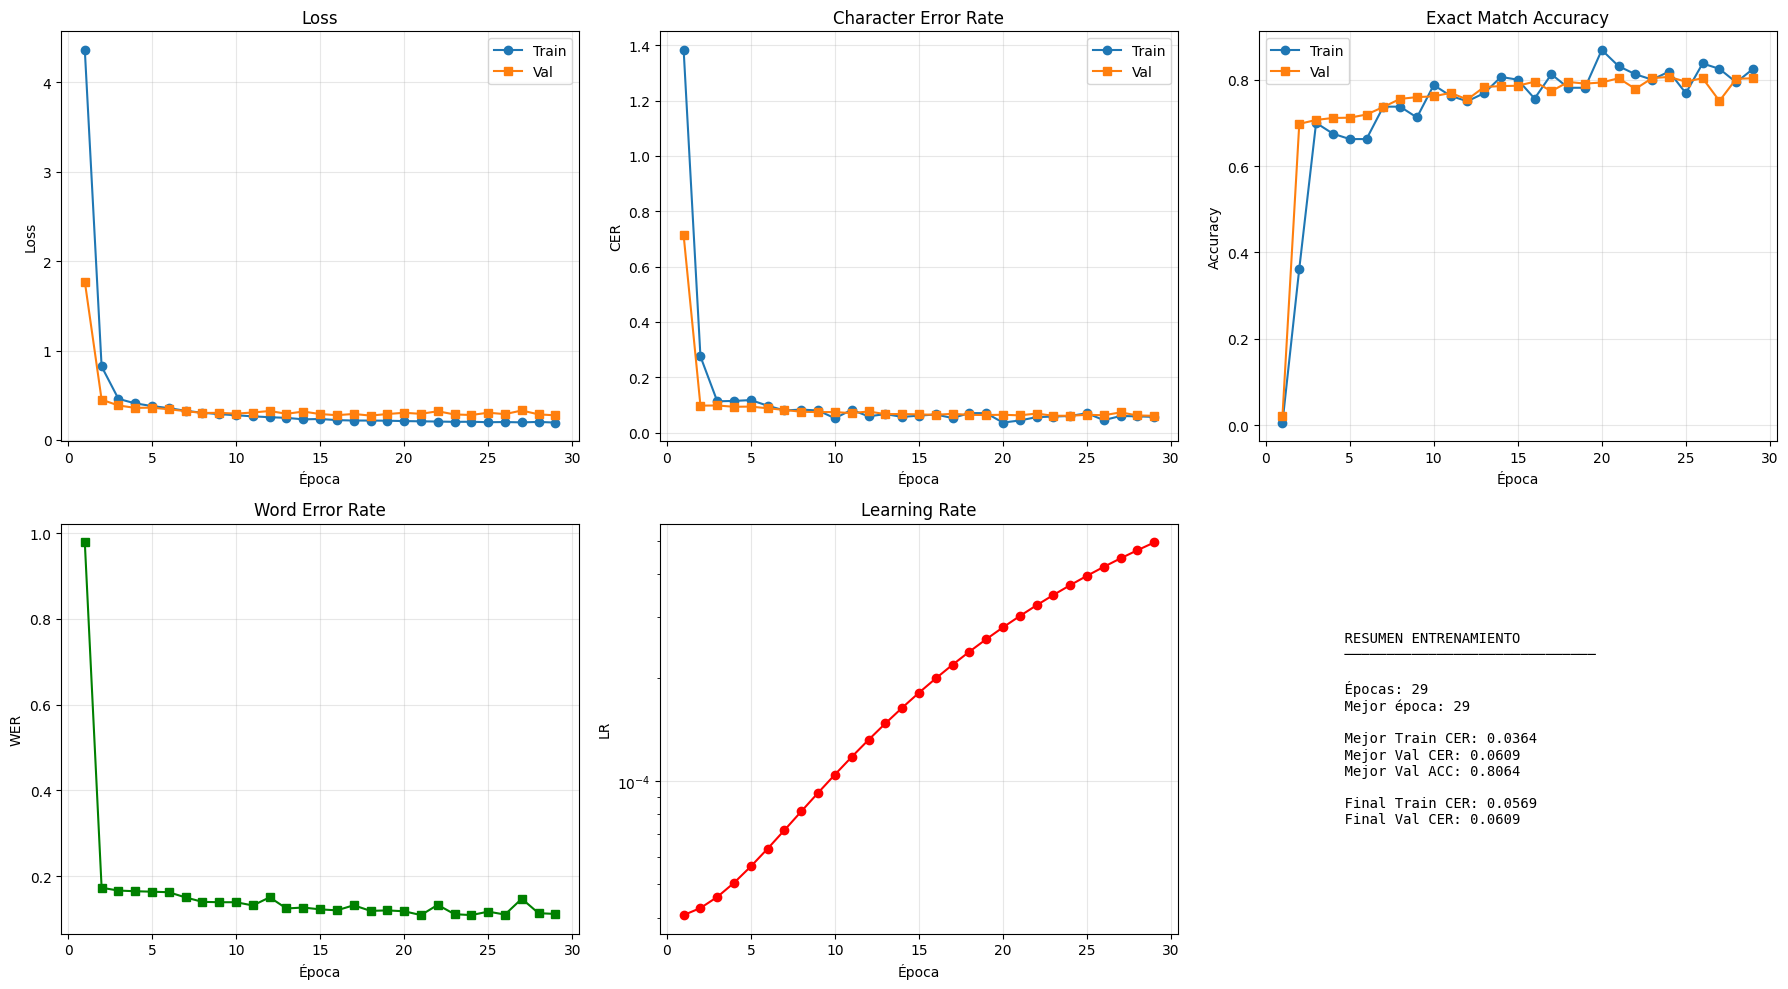

✅ Gráfica guardada en: /content/drive/MyDrive/OCR_Project/results/training_history.png


In [19]:
# ============================================================
# CELDA 18: Visualización de Resultados (VERSIÓN CORREGIDA)
# ============================================================

def plot_training_history(history):
    """Grafica historial de entrenamiento"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'o-', label='Train')
    axes[0, 0].plot(epochs, history['val_loss'], 's-', label='Val')
    axes[0, 0].set_xlabel('Época')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # CER
    axes[0, 1].plot(epochs, history['train_cer'], 'o-', label='Train')
    axes[0, 1].plot(epochs, history['val_cer'], 's-', label='Val')
    axes[0, 1].set_xlabel('Época')
    axes[0, 1].set_ylabel('CER')
    axes[0, 1].set_title('Character Error Rate')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Accuracy
    axes[0, 2].plot(epochs, history['train_acc'], 'o-', label='Train')
    axes[0, 2].plot(epochs, history['val_acc'], 's-', label='Val')
    axes[0, 2].set_xlabel('Época')
    axes[0, 2].set_ylabel('Accuracy')
    axes[0, 2].set_title('Exact Match Accuracy')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # WER
    axes[1, 0].plot(epochs, history['val_wer'], 's-', color='green')
    axes[1, 0].set_xlabel('Época')
    axes[1, 0].set_ylabel('WER')
    axes[1, 0].set_title('Word Error Rate')
    axes[1, 0].grid(True, alpha=0.3)

    # Learning Rate
    axes[1, 1].plot(epochs, history['lr'], 'o-', color='red')
    axes[1, 1].set_xlabel('Época')
    axes[1, 1].set_ylabel('LR')
    axes[1, 1].set_title('Learning Rate')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)

    # Resumen
    axes[1, 2].axis('off')
    summary = f"""
    RESUMEN ENTRENAMIENTO
    {'─'*30}

    Épocas: {len(epochs)}
    Mejor época: {np.argmin(history['val_cer']) + 1}

    Mejor Train CER: {min(history['train_cer']):.4f}
    Mejor Val CER: {min(history['val_cer']):.4f}
    Mejor Val ACC: {max(history['val_acc']):.4f}

    Final Train CER: {history['train_cer'][-1]:.4f}
    Final Val CER: {history['val_cer'][-1]:.4f}
    """
    axes[1, 2].text(0.1, 0.5, summary, fontsize=10, family='monospace', va='center')

    plt.tight_layout()
    plt.savefig(config.RESULTS_DIR / 'training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Gráfica guardada en: {config.RESULTS_DIR / 'training_history.png'}")

# ============================================================
# CARGAR HISTORY DESDE CHECKPOINT
# ============================================================

print("\n📊 Cargando historial de entrenamiento desde checkpoint...")

# Cargar el mejor checkpoint que tiene el history guardado
best_checkpoint = torch.load(config.CHECKPOINT_DIR / 'best_model.pth', map_location=device)

# Extraer history
if 'history' in best_checkpoint:
    history = best_checkpoint['history']
    print(f"✅ History cargado: {len(history['train_loss'])} épocas")

    # Graficar
    plot_training_history(history)
else:
    print("⚠️ El checkpoint no contiene history, buscando en otro checkpoint...")

    # Intentar con el último checkpoint
    import glob
    checkpoints = sorted(glob.glob(str(config.CHECKPOINT_DIR / 'checkpoint_epoch_*.pth')))

    if checkpoints:
        latest = checkpoints[-1]
        print(f"   Cargando desde: {latest}")
        checkpoint = torch.load(latest, map_location=device)

        if 'history' in checkpoint:
            history = checkpoint['history']
            print(f"✅ History cargado: {len(history['train_loss'])} épocas")
            plot_training_history(history)
        else:
            print("❌ No se encontró history en los checkpoints")
    else:
        print("❌ No se encontraron checkpoints")

In [20]:
# ============================================================
# CELDA 19: Guardar Modelo Final para Producción
# ============================================================

final_model_path = config.MODEL_DIR / 'ocr_model_final_production.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'img_height': config.IMG_HEIGHT,
        'img_width': config.IMG_WIDTH,
        'num_classes': config.NUM_CLASSES,
        'hidden_size': config.HIDDEN_SIZE,
        'num_lstm_layers': config.NUM_LSTM_LAYERS,
    },
    'vocab': {
        'chars': config.CHARS,
        'char_to_idx': config.CHAR_TO_IDX,
        'idx_to_char': config.IDX_TO_CHAR,
    },
    'performance': {
        'test_cer': test_cer,
        'test_wer': test_wer,
        'test_acc': test_acc,
    },
    'training_info': {
        'total_epochs': len(history['train_loss']),
        'best_epoch': np.argmin(history['val_cer']) + 1,
        'dataset_size': len(train_dataset),
    },
    'timestamp': datetime.now().isoformat()
}, final_model_path)

print(f"✅ Modelo final guardado en: {final_model_path}")
print(f"\n📦 ARCHIVOS GENERADOS EN GOOGLE DRIVE:")
print(f"  - Checkpoints: {config.CHECKPOINT_DIR}")
print(f"  - Modelo final: {final_model_path}")
print(f"  - Resultados: {config.RESULTS_DIR}")

✅ Modelo final guardado en: /content/drive/MyDrive/OCR_Project/models/ocr_model_final_production.pth

📦 ARCHIVOS GENERADOS EN GOOGLE DRIVE:
  - Checkpoints: /content/drive/MyDrive/OCR_Project/checkpoints
  - Modelo final: /content/drive/MyDrive/OCR_Project/models/ocr_model_final_production.pth
  - Resultados: /content/drive/MyDrive/OCR_Project/results


In [21]:
# ============================================================
# CELDA 20: Instrucciones Finales
# ============================================================

print("\n" + "="*70)
print("🎉 ¡ENTRENAMIENTO COMPLETADO CON ÉXITO!")
print("="*70)
print("""
📊 RESULTADOS FINALES:
  - Test CER: {:.4f} ({:.2f}% precisión)
  - Test ACC: {:.2f}% coincidencias exactas
  - Dataset: {:,} muestras de entrenamiento

💾 ARCHIVOS GUARDADOS EN GOOGLE DRIVE:
  - /MyDrive/OCR_Project/models/ocr_model_final_production.pth
  - /MyDrive/OCR_Project/checkpoints/ (checkpoints intermedios)
  - /MyDrive/OCR_Project/results/ (gráficas y métricas)

🔄 SI COLAB SE REINICIÓ:
  - Simplemente ejecuta de nuevo la CELDA 16
  - El entrenamiento continuará automáticamente desde el último checkpoint
  - Todo está guardado en Google Drive, no se pierde nada

📱 PRÓXIMOS PASOS:
  1. Descarga el modelo final desde Drive
  2. Usa la aplicación Gradio del script anterior
  3. ¡Prueba con tus imágenes!

🎬 PARA EL VÍDEO DEL EXAMEN:
  - Genera imágenes con generate_text_images.py
  - Muestra las gráficas de training_history.png
  - Demuestra el modelo con la app Gradio
  - Explica la arquitectura CRNN + CTC

✨ OPCIONAL - MANUSCRITO:
  - Con estas 2 semanas, podríamos entrenar un modelo para manuscrito
  - Necesitarías descargar el dataset IAM
  - Te puedo preparar el código si quieres intentarlo
""".format(test_cer, (1-test_cer)*100, test_acc*100, len(train_dataset)))

print("="*70)
print("\n🚀 ¡BUEN TRABAJO! El modelo está listo para el examen")


🎉 ¡ENTRENAMIENTO COMPLETADO CON ÉXITO!

📊 RESULTADOS FINALES:
  - Test CER: 0.0603 (93.97% precisión)
  - Test ACC: 80.78% coincidencias exactas
  - Dataset: 100,000 muestras de entrenamiento

💾 ARCHIVOS GUARDADOS EN GOOGLE DRIVE:
  - /MyDrive/OCR_Project/models/ocr_model_final_production.pth
  - /MyDrive/OCR_Project/checkpoints/ (checkpoints intermedios)
  - /MyDrive/OCR_Project/results/ (gráficas y métricas)

🔄 SI COLAB SE REINICIÓ:
  - Simplemente ejecuta de nuevo la CELDA 16
  - El entrenamiento continuará automáticamente desde el último checkpoint
  - Todo está guardado en Google Drive, no se pierde nada

📱 PRÓXIMOS PASOS:
  1. Descarga el modelo final desde Drive
  2. Usa la aplicación Gradio del script anterior
  3. ¡Prueba con tus imágenes!

🎬 PARA EL VÍDEO DEL EXAMEN:
  - Genera imágenes con generate_text_images.py
  - Muestra las gráficas de training_history.png
  - Demuestra el modelo con la app Gradio
  - Explica la arquitectura CRNN + CTC

✨ OPCIONAL - MANUSCRITO:
  - Con